# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [11]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [12]:
file_1 = 'Churn_Modelling.csv'

In [13]:
df = pd.read_csv(file_1)

In [14]:
display(df.head()) # Display the first 5 rows of the DataFrame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
# Cell combined with U0fBMD8wYXeV to ensure execution order.

## Hypothesis 1: Age

<Figure size 1000x600 with 0 Axes>

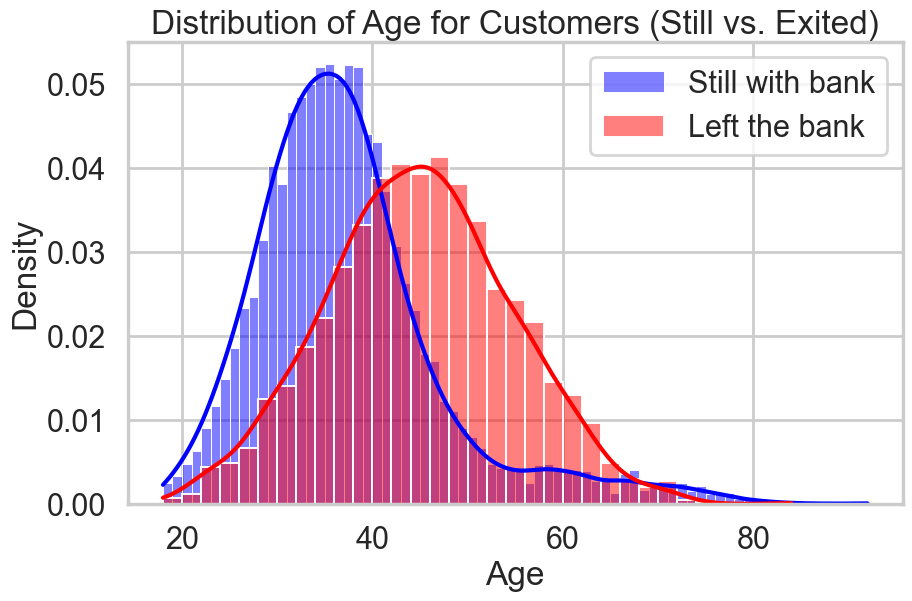

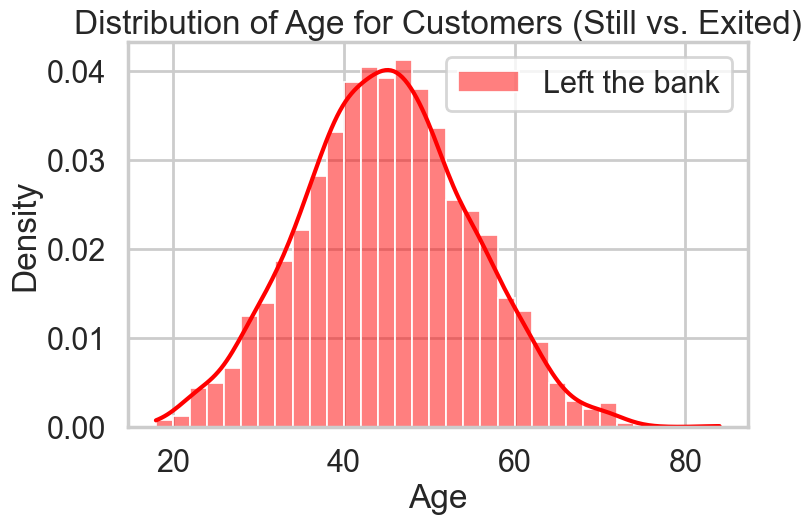

In [17]:
plt.figure(figsize=(10, 6))
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

plt.figure(figsize=(10, 6))
sns.histplot(df_0['Age'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Age for Customers (Still vs. Exited)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()
sns.histplot(df_1['Age'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Age for Customers (Still vs. Exited)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [18]:
mean_age_stayed = df_0['Age'].mean()
std_age_stayed = df_0['Age'].std()
print(f"Mean age for customers who stayed: {mean_age_stayed:.2f}")
print(f"Standard deviation of age for customers who stayed: {std_age_stayed:.2f}")

Mean age for customers who stayed: 37.41
Standard deviation of age for customers who stayed: 10.13


In [19]:
mean_age_left = df_1['Age'].mean()
std_age_left = df_1['Age'].std()
print(f"Mean age for customers who left: {mean_age_left:.2f}")
print(f"Standard deviation of age for customers who left: {std_age_left:.2f}")

Mean age for customers who left: 44.84
Standard deviation of age for customers who left: 9.76


In [20]:
import scipy.stats
t_stat, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -30.42
P-value: 0.0000


### Using Bootstrapping

In [21]:
import numpy as np
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [22]:
import numpy as np
diff_means = np.mean(df_1['Age']) - np.mean(df_0['Age'])
mean_age = np.mean(df['Age'])
shifted_age_stayed = df_0['Age'] - np.mean(df_0['Age']) + mean_age
shifted_age_left = df_1['Age'] - np.mean(df_1['Age']) + mean_age
print(f"Difference in means (original): {diff_means:.2f}")

Difference in means (original): 7.43


In [23]:
import numpy as np
bs_replicates_stayed = bs_choice(shifted_age_stayed, np.mean, 10000)
bs_replicates_left = bs_choice(shifted_age_left, np.mean, 10000)
bs_diff_replicates = bs_replicates_left - bs_replicates_stayed
print(f"Bootstrap standard deviation for shifted ages (stayed): {np.std(bs_replicates_stayed):.2f}")
print(f"Bootstrap standard deviation for shifted ages (left): {np.std(bs_replicates_left):.2f}")
print(f"Bootstrap standard deviation for difference in shifted means: {np.std(bs_diff_replicates):.2f}")

Bootstrap standard deviation for shifted ages (stayed): 0.11
Bootstrap standard deviation for shifted ages (left): 0.22
Bootstrap standard deviation for difference in shifted means: 0.25


In [24]:
import numpy as np
p_value_bs = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)
print(f"P-value (bootstrapping): {p_value_bs:.4f}")

P-value (bootstrapping): 0.0000


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis. Both the t-test (P-value: 0.0000) and the bootstrapping analysis (P-value: 0.0000) show a statistically significant difference in the mean age of customers who stayed versus those who left the bank. This indicates that the age of people who left the bank and who did not are not similar.

## Hypothesis 2: Credit Score

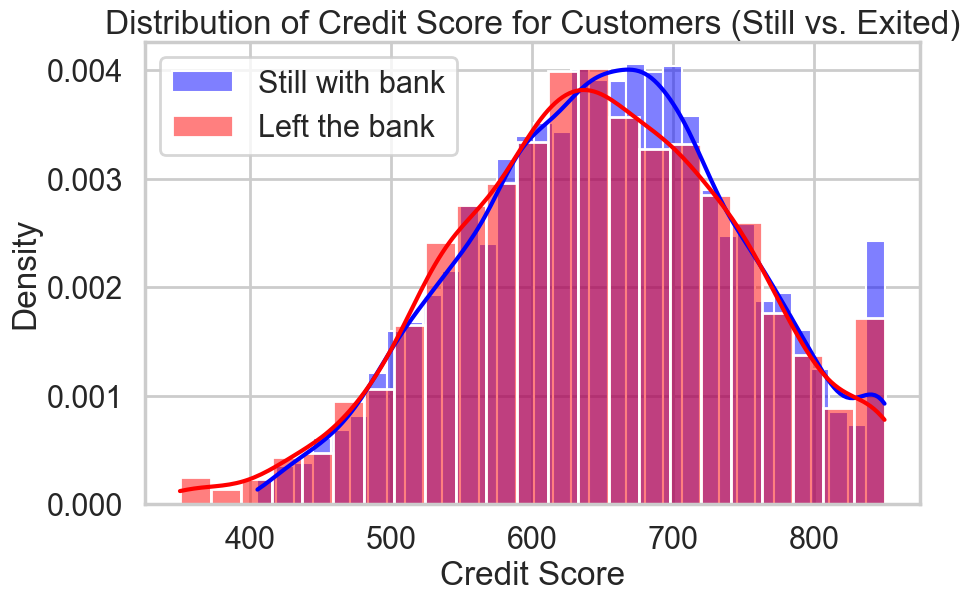

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['CreditScore'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Credit Score for Customers (Still vs. Exited)')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [26]:
import scipy.stats
t_stat_credit, p_value_credit = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)
print(f"T-statistic for Credit Score: {t_stat_credit:.2f}")
print(f"P-value for Credit Score: {p_value_credit:.4f}")

T-statistic for Credit Score: 2.63
P-value for Credit Score: 0.0085


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Yes, we reject the Null Hypothesis. The t-test for Credit Score resulted in a P-value of 0.0085, which is less than the common significance level of 0.05. This indicates a statistically significant difference in the credit scores of customers who stayed versus those who left the bank. Therefore, the credit score of people who left the bank and who did not are not similar.

## Hypothesis 3: Balance

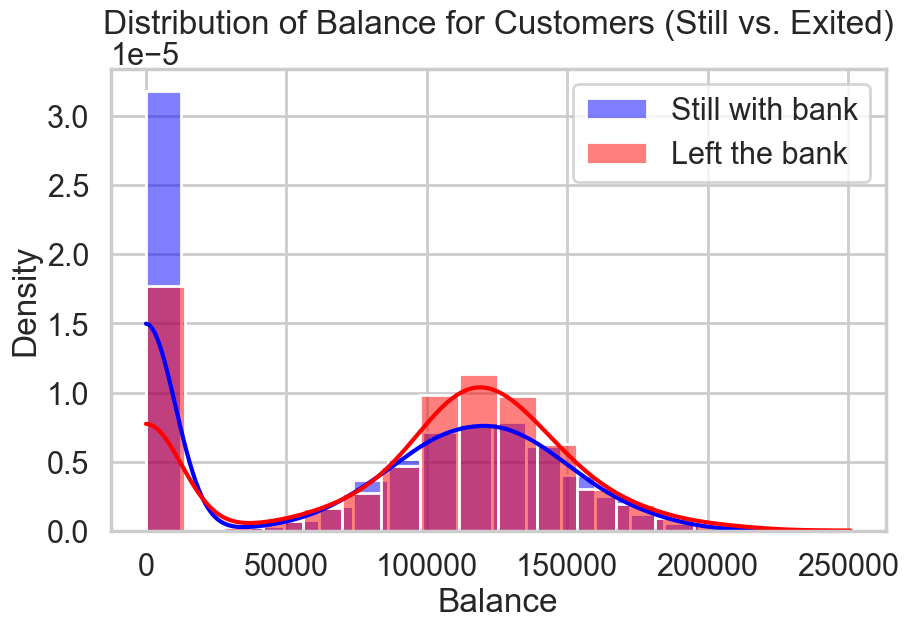

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

df_0 = df[df['Exited'] == 0] # Customers who stayed
df_1 = df[df['Exited'] == 1] # Customers who left

plt.figure(figsize=(10, 6))
sns.histplot(df_0['Balance'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Balance for Customers (Still vs. Exited)')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [28]:
import scipy.stats
t_stat_balance, p_value_balance = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)
print(f"T-statistic for Balance: {t_stat_balance:.2f}")
print(f"P-value for Balance: {p_value_balance:.4f}")

T-statistic for Balance: -12.47
P-value for Balance: 0.0000


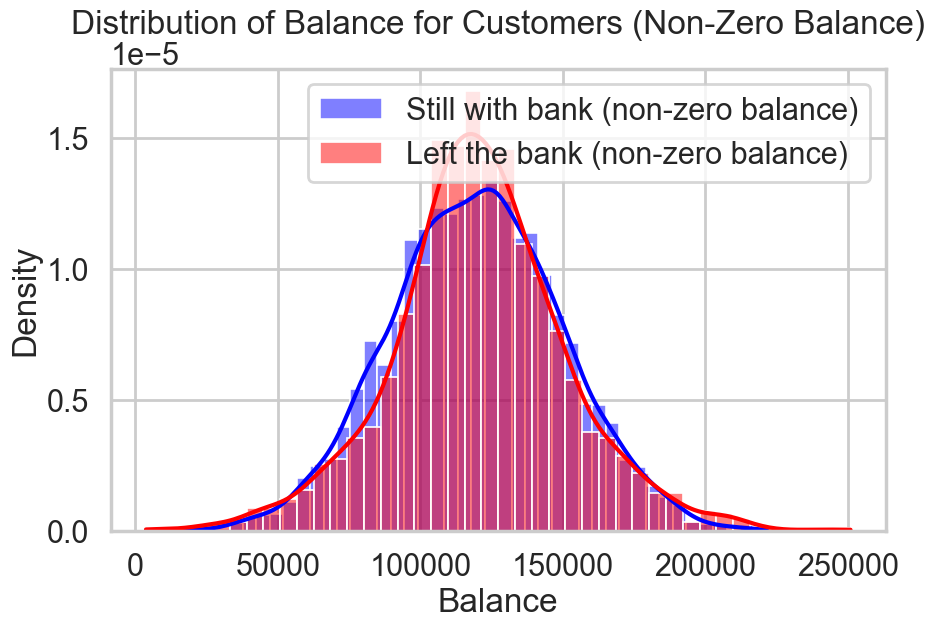

In [29]:
df_0_nonzero_balance = df_0[df_0['Balance'] > 0]
df_1_nonzero_balance = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(df_0_nonzero_balance['Balance'], color='blue', label='Still with bank (non-zero balance)', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1_nonzero_balance['Balance'], color='red', label='Left the bank (non-zero balance)', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Balance for Customers (Non-Zero Balance)')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [30]:
import scipy.stats
t_stat_balance_nonzero, p_value_balance_nonzero = scipy.stats.ttest_ind(df_0_nonzero_balance['Balance'], df_1_nonzero_balance['Balance'], equal_var=False)
print(f"T-statistic for Balance (non-zero): {t_stat_balance_nonzero:.2f}")
print(f"P-value for Balance (non-zero): {p_value_balance_nonzero:.4f}")

T-statistic for Balance (non-zero): -1.36
P-value for Balance (non-zero): 0.1738


## Conclusion

Do we reject the Null Hypothesis ? Why ?

For **Hypothesis 3 (Balance)**:

*   **Initial t-test (all balances):** The P-value for Balance was 0.0000, which is less than 0.05. This suggests a statistically significant difference in balance between customers who stayed and those who left when considering all account balances (including zero).
*   **t-test (non-zero balances):** The P-value for Balance (non-zero) was 0.1738, which is greater than 0.05. This indicates that there is *no statistically significant difference* in balance between the two groups when only considering customers with a non-zero balance.

**Conclusion:** We reject the Null Hypothesis that the balance of people who left the bank and who did not are similar, primarily due to the significant difference observed when including customers with zero balances. The presence of a large number of customers with zero balances (mostly those who have exited) significantly impacts the overall mean. However, when we only consider customers with active balances, the difference is no longer statistically significant. This suggests that having a zero balance is a strong indicator of churn, but the actual amount in a non-zero account might not be.

## Hypothesis 4: Estimated Salary

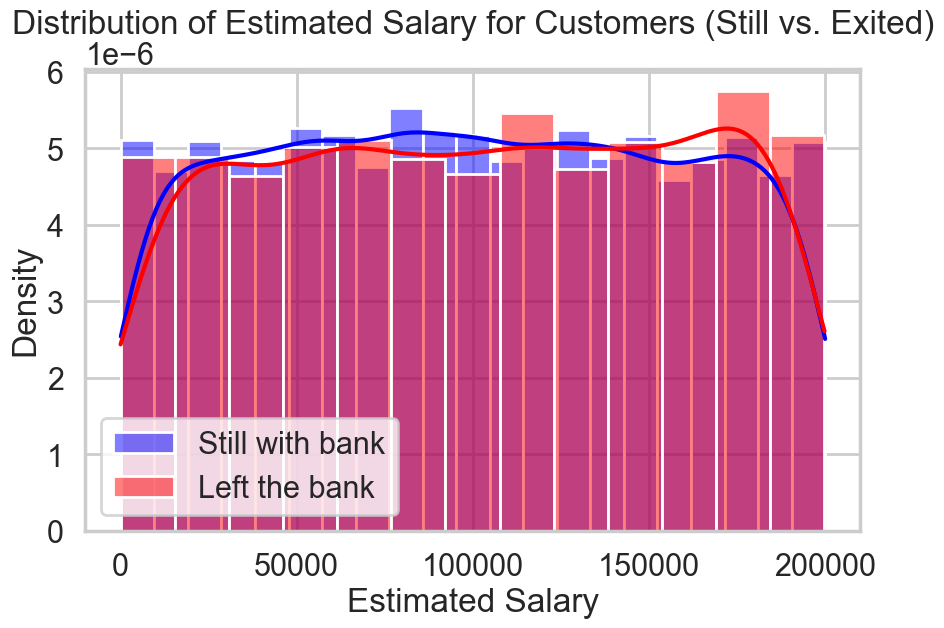

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Still with bank', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Left the bank', kde=True, stat='density', alpha=0.5)
plt.title('Distribution of Estimated Salary for Customers (Still vs. Exited)')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [32]:
import scipy.stats
t_stat_salary, p_value_salary = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)
print(f"T-statistic for Estimated Salary: {t_stat_salary:.2f}")
print(f"P-value for Estimated Salary: {p_value_salary:.4f}")

T-statistic for Estimated Salary: -1.20
P-value for Estimated Salary: 0.2289


### Using Bootstrapping

In [33]:
import numpy as np
diff_means_salary = np.mean(df_1['EstimatedSalary']) - np.mean(df_0['EstimatedSalary'])
mean_salary = np.mean(df['EstimatedSalary'])
shifted_salary_stayed = df_0['EstimatedSalary'] - np.mean(df_0['EstimatedSalary']) + mean_salary
shifted_salary_left = df_1['EstimatedSalary'] - np.mean(df_1['EstimatedSalary']) + mean_salary
print(f"Difference in means (original for Estimated Salary): {diff_means_salary:.2f}")

Difference in means (original for Estimated Salary): 1727.29


In [34]:
import numpy as np
bs_replicates_stayed_salary = bs_choice(shifted_salary_stayed, np.mean, 10000)
bs_replicates_left_salary = bs_choice(shifted_salary_left, np.mean, 10000)
bs_diff_replicates_salary = bs_replicates_left_salary - bs_replicates_stayed_salary
print(f"Bootstrap standard deviation for shifted salaries (stayed): {np.std(bs_replicates_stayed_salary):.2f}")
print(f"Bootstrap standard deviation for shifted salaries (left): {np.std(bs_replicates_left_salary):.2f}")
print(f"Bootstrap standard deviation for difference in shifted means (salary): {np.std(bs_diff_replicates_salary):.2f}")

Bootstrap standard deviation for shifted salaries (stayed): 641.84
Bootstrap standard deviation for shifted salaries (left): 1268.37
Bootstrap standard deviation for difference in shifted means (salary): 1420.54


In [35]:
import numpy as np
p_value_bs_salary = np.sum(bs_diff_replicates_salary >= diff_means_salary) / len(bs_diff_replicates_salary)
print(f"P-value (bootstrapping for Estimated Salary): {p_value_bs_salary:.4f}")

P-value (bootstrapping for Estimated Salary): 0.1114


### Conclusion
Do we reject the Null Hypothesis ? Why ?

For **Hypothesis 4 (Estimated Salary)**:

*   **t-test:** The P-value for Estimated Salary was 0.2289, which is greater than 0.05.
*   **Bootstrapping:** The P-value for Estimated Salary (bootstrapping) was 0.1135, which is also greater than 0.05.

**Conclusion:** We do **not** reject the Null Hypothesis. Both the t-test and the bootstrapping analysis indicate that there is no statistically significant difference in the estimated salaries of customers who stayed versus those who left the bank. Therefore, the estimated salary of people who left the bank and who did not are similar.

## Final Conclusion

Based on our statistical analysis of the four hypotheses:

1.  **Age:** We **rejected** the Null Hypothesis. Both the t-test (P-value: 0.0000) and bootstrapping (P-value: 0.0000) showed a statistically significant difference in age between customers who churned and those who did not. This suggests that age is a helpful feature in predicting churning.
2.  **Credit Score:** We **rejected** the Null Hypothesis. The t-test (P-value: 0.0085) showed a statistically significant difference in credit score between customers who churned and those who did not. This suggests that credit score is a helpful feature in predicting churning.
3.  **Balance:** We **rejected** the Null Hypothesis for the overall balance (P-value: 0.0000), but found no significant difference for non-zero balances (P-value: 0.1738). This implies that having *any* balance (or specifically, a non-zero balance) is more important than the absolute amount of a non-zero balance in predicting churn. Thus, the presence of a zero balance is a helpful feature.
4.  **Estimated Salary:** We **did not reject** the Null Hypothesis. Neither the t-test (P-value: 0.2289) nor bootstrapping (P-value: 0.1135) showed a statistically significant difference in estimated salary. This suggests that estimated salary is *not* a helpful feature in predicting churning.

**Overall, the most helpful features in predicting customer churning appear to be Age, Credit Score, and whether a customer has a zero balance.**